# Project 4 MLFI

# Exercise 1

### Question 1.a

Check that $ S_t = s_0 \exp \left( \sigma W_t - \frac{1}{2} \sigma^2 t \right)$ solves the Black-Scholes SDE.

$$
\text{Let } S_t = s_0 \exp\!\left(\sigma W_t - \tfrac12 \sigma^2 t\right).
$$

$$
f(t,W_t) = \exp\!\left(\sigma W_t - \tfrac12 \sigma^2 t\right).
$$

Using Ito's formula:
$$
d f(t,W_t)
= \frac{\partial f}{\partial t}\, dt
+ \frac{\partial f}{\partial W}\, dW_t
+ \frac12 \frac{\partial^2 f}{\partial W^2}\, (dW_t)^2 .
$$

Compute derivatives:
$$
\frac{\partial f}{\partial t}
= -\tfrac12\sigma^2 f, 
\qquad
\frac{\partial f}{\partial W}
= \sigma f,
\qquad
\frac{\partial^2 f}{\partial W^2}
= \sigma^2 f.
$$

Substitute into Ito's formula and use $(dW_t)^2 = dt$:
$$
df = 
\left(-\tfrac12\sigma^2 f\right) dt
+ \sigma f\, dW_t
+ \tfrac12 \sigma^2 f\, dt.
$$

The drift terms cancel:
$$
df = \sigma f\, dW_t .
$$

Since $S_t = s_0 f(t,W_t)$, we get:
$$
dS_t = s_0\, df = \sigma S_t\, dW_t.
$$

Thus
$$
dS_t = \sigma S_t\, dW_t,
\qquad
S_0 = s_0,
$$

which shows that 
$
S_t = s_0 e^{\sigma W_t - \frac12\sigma^2 t}
$
is indeed a solution of the SDE.
$$


### Question 1.b - Generate dataset

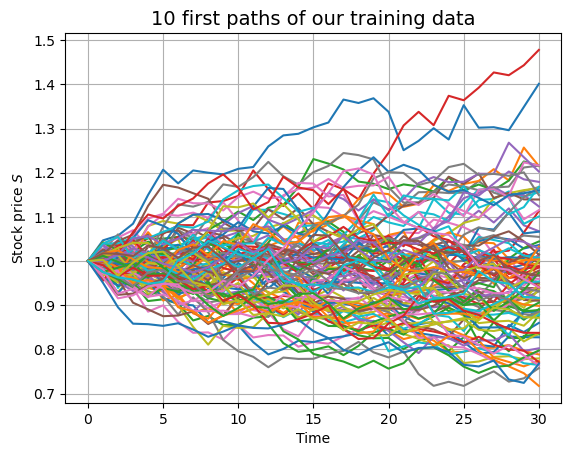

In [32]:
# Generate the training set
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

sigma = 0.5
N = 30
T = N/365
K = 1


def simulate_paths_bs(m, N):
    Z = np.random.normal(size = (m, N))
    S = np.zeros((m, N + 1))
    S[:,0] = 1

    for j in range(N):
        S[:, j+1] = S[:, j]*np.exp(-0.5 * sigma**2*(T/N) + sigma*np.sqrt(T / N)* Z[:, j])
    
    return S

S_train = simulate_paths_bs(m = int(1e5), N = N)


for i in range(100):
    plt.plot(S_train[i])
plt.title("10 first paths of our training data", fontsize = 14)
plt.xlabel("Time")
plt.ylabel(r"Stock price $S$")
plt.grid(True)
plt.show()


# Generate the test set

S_test = simulate_paths_bs(m = int(1e4), N = N)

### Question 1.c - Model implementation

In [ ]:
# Building the smaller class of smaller models used at each time (shallow models) 

import torch 
import torch.nn as nn


class shallow_model(nn.Module):
    def __init__(self, hidden_dim, activation):
        super().__init__() # allows our small models to inherit from all Pytoch needs to train the model
        self.shallow_model = nn.Sequential(
            nn.Linear(1, hidden_dim, bias=True), activation, nn.Linear(hidden_dim, 1, bias = True)
        )

    def forward(self, S_t):
        H_t = self.shallow_model(S_t)
        return H_t
    

# Building the class of slightly bigger models (deeper, 2 layers instead of 1)

class deep_model(nn.Module):
    def __init__(self, hidden_dim, activation):
        super().__init__() # allows our small models to inherit from all Pytorch needs to train the model
        self.deep_model = nn.Sequential(
            nn.Linear(1, hidden_dim, bias=True), activation, nn.Linear(hidden_dim, hidden_dim, bias = True), 
            activation, nn.Linear(hidden_dim, 1, bias = True)
        )

    def forward(self, S_t):
        H_t = self.deep_model(S_t)
        return H_t

# The full model which contains all the submodels using nn.ModuleList

class DeepHedgerBS(nn.Module):
    def __init__(self, N, type_submodel, hidden_dim = 16, activation = nn.ReLU()):
        super().__init__()
        self.N = N
        if type_submodel == 'Shallow':
            self.submodels = nn.ModuleList([shallow_model(hidden_dim = hidden_dim, activation = activation) for _ in range(N)])

        if type_submodel == 'Deep':
            self.submodels = nn.ModuleList([deep_model(hidden_dim = hidden_dim, activation = activation) for _ in range(N)])
        
        elif (type_submodel != 'Deep' and type_submodel != 'Shallow'):
            print("Wrong specified model, please change type of submodel for H")
    
    def forward(self, S_paths, p):
        dS = S_paths[:, 1:] - S_paths[:, :-1]
        H_list = []

        for j in range(N):
            S_t_j = S_paths[:, j:j+1]
            H_t_j = self.submodels[j](S_t_j)
            H_list.append(H_t_j)

        H = torch.cat(H_list, dim = 1)
        hedge_pnl = torch.sum(H * dS, dim = 1)
        return hedge_pnl
    


# Implement the payoff function of a call option (Loss function of our model)

def loss_function_BS_option(hedge_pnl, p, payoff_batch):
    L = payoff_batch - p - hedge_pnl
    return (L**2).mean()


# The helper function to train our Deep Hedger

def train_deep_hedger(model, S_train, payoff_train, p,
                      num_epochs=10, batch_size=1024, lr=1e-3, device="cpu", plot_loss = True, print_statements =  True,
                      print_results = False):
    
    model.to(device)

    S_train_tensor = torch.from_numpy(S_train).float().to(device)          # (m_train, N+1)
    payoff_train_tensor = torch.from_numpy(payoff_train).float().to(device)  # (m_train,)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    m = S_train_tensor.size(0)
    list_train_losses = []
    list_test_losses = []

    for epoch in range(num_epochs):
        # Shuffle path indices each epoch
        perm = torch.randperm(m, device=device)

        for start in range(0, m, batch_size):
            idx = perm[start:start + batch_size]

            S_batch = S_train_tensor[idx]           # (batch_size, N+1)
            payoff_batch = payoff_train_tensor[idx] # (batch_size,)

            # Forward pass: hedge PnL for the batch
            hedge_pnl = model(S_batch, p)

            loss = loss_function_BS_option(hedge_pnl, p, payoff_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        list_train_losses.append(loss.item())
        S_test_tensor = torch.from_numpy(S_test).float().to(device)
        payoff_test = torch.from_numpy(np.maximum(S_test[:, -1] - K, 0)).float().to(device)
        hedge_pnl_test = model(S_test_tensor, p)
        loss_test = loss_function_BS_option(hedge_pnl_test, p, payoff_test)
        list_test_losses.append(loss_test.item())
        
        if print_statements == True:
            print(f"Epoch {epoch+1}/{num_epochs}, loss train = {loss.item():.6f}, loss test = {loss_test.item():.6f}")

        
    if plot_loss==True:
        plt.plot([i for i in range(1, num_epochs + 1)], list_train_losses, label = 'Training loss')
        plt.plot([i for i in range(1, num_epochs + 1)], list_test_losses, label = 'Test loss')
        plt.title("Train test loss during training")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()
    
    return model


# Function to evaluate hedging loss

def evaluate_deep_hedger(model, S_test, payoff_test, p, device="cpu"):
    
    model.to(device)
    model.eval()

    S_test_tensor = torch.from_numpy(S_test).float().to(device)           # (m_test, N+1)
    payoff_test_tensor = torch.from_numpy(payoff_test).float().to(device) # (m_test,)

    with torch.no_grad():
        hedge_pnl_test = model(S_test_tensor, p)                           # (m_test,)
        L_test = payoff_test_tensor - p - hedge_pnl_test                   # hedging error

    mean_L = L_test.mean().item()
    std_L = L_test.std().item()

    return L_test.cpu().numpy()

### Question 1.d - Model training

In [ ]:
# Implement a function that returns the Black-Scholes price of a call option with given strike and maturity

from scipy.stats import norm

def bs_call_price(S0, K, T, sigma, r=0.0):
    sqrtT = np.sqrt(T)
    d_plus = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d_minus = d_plus - sigma * sqrtT
    C = norm.cdf(d_plus) * S0 - norm.cdf(d_minus) * K * np.exp(-r * T)
    return C


p = bs_call_price(S0 = 1, K = 1, T = 30/365, sigma = 0.5)


S_T_train = S_train[:,-1]
S_T_test = S_test[:,-1]

payoff_train = np.maximum(S_T_train - K, 0)
payoff_test = np.maximum(S_T_test - K, 0)


# Big custom grid search for best model

results = []
for hidden_dim in [16, 32]:
    for activation_function in [nn.ReLU(), nn.Tanh()]: #nn.LeakyReLU(), nn.Tanh()
        for type_submodel in ['Shallow', 'Deep']:
            for epochs in [50 ,100]:
                print(f"TRAINING - type submodel = {type_submodel} - activation : {str(activation_function)} - epochs : {epochs} - Hidden dim : {hidden_dim}")
                model = DeepHedgerBS(N = N, type_submodel = type_submodel, hidden_dim = hidden_dim,
                                 activation = activation_function)
            
                model = train_deep_hedger(model, S_train=S_train, payoff_train=payoff_train,
                                      p = p, num_epochs = epochs, batch_size = 1024, lr = 1e-3,
                                      device='cpu', plot_loss= False, print_statements= False,
                                      print_results = True)
                
                L_test = evaluate_deep_hedger(model, S_test=S_test, payoff_test = payoff_test,
                                              p = p, device="cpu")
                mean_loss = L_test.mean().item()
                std_loss  = L_test.std().item()

                print(f"     Mean of loss on test set : {mean_loss:.7f}")
                print(f"     STD of loss on test set  : {std_loss:.7f}\n")

                results.append({
                    "hidden_dim": hidden_dim,
                    "activation": activation_function.__class__.__name__,
                    "type_submodel": type_submodel,
                    "epochs": epochs,
                    "mean_loss": mean_loss,
                    "std_loss": std_loss,
                })


# now pick best configs
best_by_abs_mean = min(results, key=lambda r: abs(r["mean_loss"]))
best_by_std      = min(results, key=lambda r: r["std_loss"])
print("Best config by abs(mean) :", best_by_abs_mean)
print("Best config by std  :", best_by_std)


TRAINING - type submodel = Shallow - activation : ReLU() - epochs : 50 - Hidden dim : 16
     Mean of loss on test set : -0.0000569
     STD of loss on test set  : 0.0138360

TRAINING - type submodel = Shallow - activation : ReLU() - epochs : 100 - Hidden dim : 16
     Mean of loss on test set : -0.0000625
     STD of loss on test set  : 0.0125904

TRAINING - type submodel = Deep - activation : ReLU() - epochs : 50 - Hidden dim : 16
     Mean of loss on test set : -0.0001064
     STD of loss on test set  : 0.0094987

TRAINING - type submodel = Deep - activation : ReLU() - epochs : 100 - Hidden dim : 16
     Mean of loss on test set : -0.0001460
     STD of loss on test set  : 0.0098587

TRAINING - type submodel = Shallow - activation : Tanh() - epochs : 50 - Hidden dim : 16
     Mean of loss on test set : -0.0001502
     STD of loss on test set  : 0.0171544

TRAINING - type submodel = Shallow - activation : Tanh() - epochs : 100 - Hidden dim : 16
     Mean of loss on test set : -0.0001

After running the grid search above, we decide to choose the second model displayed in the cell above (Best config by std) that minimizes the standard deviation of the loss over the test set. This model has a slightly higher absolute mean than the best config by absolute mean. However, since both means are comparable and close to 0, we choose the config that minimizes the std.

Epoch 1/100, loss train = 0.001034, loss test = 0.001032
Epoch 2/100, loss train = 0.000522, loss test = 0.000477
Epoch 3/100, loss train = 0.000356, loss test = 0.000345
Epoch 4/100, loss train = 0.000471, loss test = 0.000318
Epoch 5/100, loss train = 0.000312, loss test = 0.000309
Epoch 6/100, loss train = 0.000309, loss test = 0.000301
Epoch 7/100, loss train = 0.000281, loss test = 0.000296
Epoch 8/100, loss train = 0.000329, loss test = 0.000290
Epoch 9/100, loss train = 0.000256, loss test = 0.000286
Epoch 10/100, loss train = 0.000402, loss test = 0.000277
Epoch 11/100, loss train = 0.000250, loss test = 0.000275
Epoch 12/100, loss train = 0.000247, loss test = 0.000263
Epoch 13/100, loss train = 0.000248, loss test = 0.000251
Epoch 14/100, loss train = 0.000227, loss test = 0.000244
Epoch 15/100, loss train = 0.000240, loss test = 0.000233
Epoch 16/100, loss train = 0.000208, loss test = 0.000226
Epoch 17/100, loss train = 0.000200, loss test = 0.000215
Epoch 18/100, loss trai

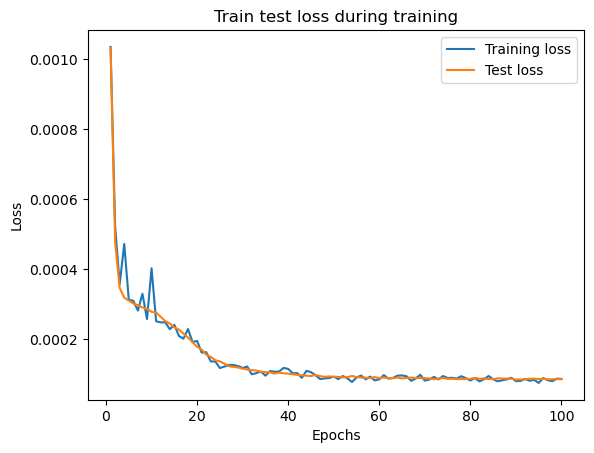



Mean of loss on test set : -0.0001269
STD of loss on test set  : 0.0091959



In [36]:
best_model = DeepHedgerBS(N = N, type_submodel = 'Deep', hidden_dim = 32,
                                 activation = nn.Tanh())

best_model = train_deep_hedger(best_model, S_train=S_train, payoff_train=payoff_train,
                                      p = p, num_epochs = 100, batch_size = 1024, lr = 1e-3,
                                      device='cpu', plot_loss= True, print_statements= True,
                                      print_results = False)

L_test = evaluate_deep_hedger(best_model, S_test = S_test, payoff_test = payoff_test,
                                              p = p, device="cpu")
mean_loss = L_test.mean().item()
std_loss  = L_test.std().item()

print("\n")
print(f"Mean of loss on test set : {mean_loss:.7f}")
print(f"STD of loss on test set  : {std_loss:.7f}\n")

### Question 1.e - Model evaluation

Empirical mean of loss on test set : -0.000127
Empirical std of loss on test set  : 0.009196


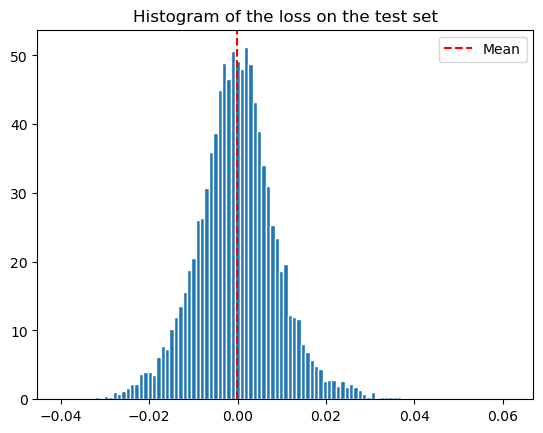

In [38]:
# Evaluate the hedging losses on the test set
L_test = evaluate_deep_hedger(
    best_model,
    S_test=S_test,
    payoff_test=payoff_test,
    p=p,
    device="cpu"
)

print(f"Empirical mean of loss on test set : {L_test.mean().item():.6f}")
print(f"Empirical std of loss on test set  : {L_test.std().item():.6f}")


# Plot a histogram of the hedging losses and print mean and standard deviation

plt.hist(L_test, bins = 'auto', density = True, edgecolor = 'white')
plt.title("Histogram of the loss on the test set")
plt.axvline(L_test.mean(), linestyle= '--', color='red', label='Mean')
plt.legend()
plt.show()


The hedging losses are centered almost exactly at zero, with a negligible mean and a small standard deviation, showing that the deep hedging model produces an unbiased and accurate replication under Black–Scholes dynamics. The histogram is narrow and symmetric, consistent with the expected residual risk from discrete hedging. 

### Question 1.f(i) - Compute analytical solution

Show a **step-by-step** derivation of the analytical hedging strategy:



$$
H^{\text{BS}}_t(s) =\frac{\partial C}{\partial s}(s,t)
= \Phi(d_+(s,t))
+
s\,\phi(d_+(s,t))\frac{\partial d_+}{\partial s}
-
K e^{-r(T-t)}\phi(d_-(s,t))\frac{\partial d_-}{\partial s},
$$

$$
\frac{\partial d_+}{\partial s}
= \frac{1}{s\sigma\sqrt{T-t}},
\qquad
\frac{\partial d_-}{\partial s}
= \frac{1}{s\sigma\sqrt{T-t}},
$$

$$
K e^{-r(T-t)}\phi(d_-(s,t))
= s\,\phi(d_+(s,t)),
$$

$$
\Longrightarrow \quad
H_t^{BS}(s)=\Phi(d_+(s,t)).
$$




### Question 1.f(ii) - Losses comparison with analytical solution

Mean of analytical loss computed on test set :  -9.3e-05
Standard deviation of analytical loss on test set :  0.008951 



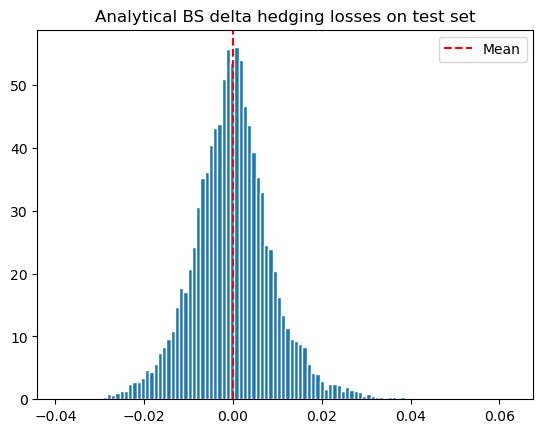

In [ ]:
# Implement the formula you found

def analytic_H_t(s, t, S0, sigma, T):
    s = np.asarray(s)
    tau = T - t   # time to maturity

    d_plus = (np.log(s / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d_plus)


def bs_call_delta(S, K, tau, sigma, r=0.0):
    S = np.asarray(S)
    tau = np.asarray(tau)

    sqrt_tau = np.sqrt(tau)
    d_plus = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * sqrt_tau)
    return norm.cdf(d_plus)


def compute_analytical_losses(S_paths, K, T, sigma, p, r=0.0):
    
    S_paths = np.asarray(S_paths)
    m, N_plus_1 = S_paths.shape
    N = N_plus_1 - 1
    dt = T / N

    # Time grid at which you rebalance (left endpoints)
    t_grid = np.linspace(0.0, T - dt, N)          # shape (N,)
    tau_grid = T - t_grid                         # time to maturity, shape (N,)

    # Underlying prices at hedge times
    S_t = S_paths[:, :-1]                         # shape (m, N)

    # Broadcast tau over all paths
    tau_mat = tau_grid.reshape(1, -1)             # shape (1, N)

    # Compute deltas at each time step
    Delta = bs_call_delta(S_t, K, tau_mat, sigma, r)   # shape (m, N)

    # Price increments
    dS = S_paths[:, 1:] - S_paths[:, :-1]         # shape (m, N)

    # Hedging P&L from the BS delta strategy
    hedge_pnl = np.sum(Delta * dS, axis=1)        # shape (m,)

    # Payoff at maturity
    payoff = np.maximum(S_paths[:, -1] - K, 0.0)  # shape (m,)

    # Pathwise loss
    L = payoff - p - hedge_pnl
    return L

# Plot a histograms of the hedging losses (analytical and deep hedging) and print means and standard deviations

K = 1
T = 30/365
sigma = 0.5

# p already defined from bs_call_price(S0=1, K=1, T=30/365, sigma=0.5)
analytical_losses_test = compute_analytical_losses(S_test, K=K, T=T, sigma=sigma, p=p)

print("Mean of analytical loss computed on test set : ", round(analytical_losses_test.mean(), 6))
print("Standard deviation of analytical loss on test set : ", round(analytical_losses_test.std(), 6), "\n")

plt.hist(analytical_losses_test, bins='auto', density=True, edgecolor='white')
plt.axvline(analytical_losses_test.mean(), linestyle = '--', color = 'red', label = 'Mean')
plt.title("Analytical BS delta hedging losses on test set")
plt.legend()
plt.show()


The losses are still centered almost exactly at zero, with a negligible mean and a small standard deviation. This histogram of the analytical solutions agrees with the results of our neural network model above : the mean is very close to 0 in both cases ($\approx10^{-5}$) and the std is of the same order of magnitude with that of the analytical solution.

How does your deep hedging model compare with the analytical solution? If it's worse, you must improve its performance. A few questions for you to consider...

Have you trained your deep hedging model well?
- Are the losses centered on zero? ($10^{-5} \approx 0$)
- Is their standard deviation comparable with that of the analytical solution?

How can you improve performance?
- train for more epochs
- try a different learning rate
- change the networks' architectures (first try more hidden neurons, then try more hidden layers)
- try different batch sizes
- use a learning rate scheduler (see https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)
- try a different activation function (e.g. $\tanh$)
- implement regularization (use the `weight_decay` argument in the optimizer)
- implement batch-normalization (see https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
- experiment with different optimizers
- ask in the forum

OUR ANSWER : we tried different changing different parameters in our implementation with a custom grid search through the following hyperparameters : activation function, depth of the neural networks, hidden dimension, and number of epochs.

### Question 1.g - Learned strategy comparison with analytical solution

- For what times $t_j$ are the two functions most similar? 
- Why?

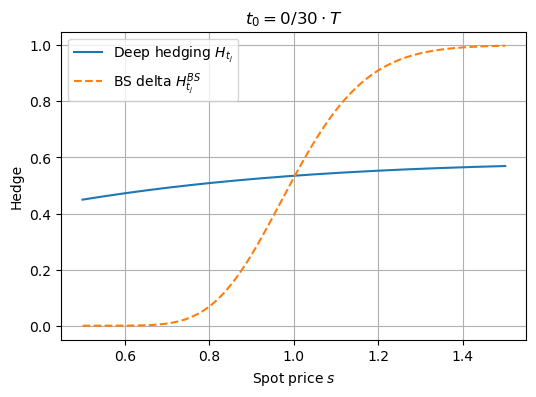

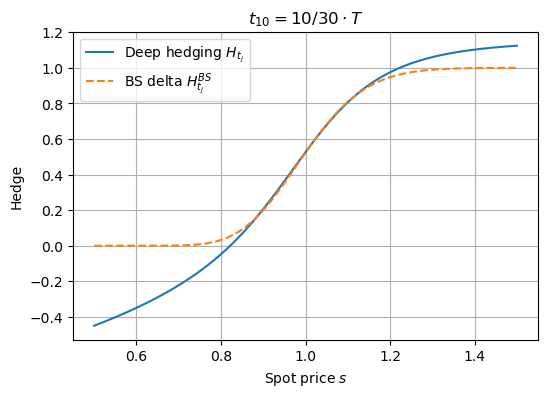

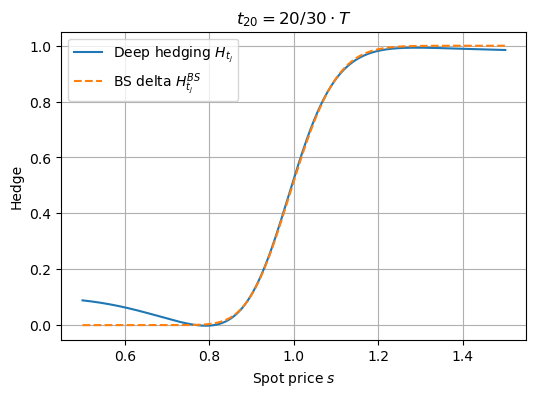

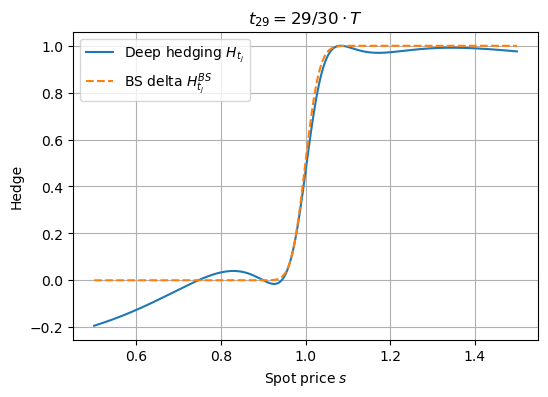

In [39]:
indices_j = [0, 10, 20, 29]
times = np.linspace(0, T - T/N, N)

s = np.linspace(0.5, 1.5, 500)
s_torch = torch.from_numpy(s).float().unsqueeze(1)

with torch.no_grad():
    for j in indices_j:
        plt.figure(figsize=(6,4))
        
        plt.plot(
            s,
            best_model.submodels[j].forward(s_torch).squeeze(1).numpy(),
            label='Deep hedging $H_{t_j}$',
            color='C0'
        )
        
        plt.plot(
            s,
            analytic_H_t(s, t=times[j], S0=1, sigma=0.5, T=30/365),
            label='BS delta $H^{BS}_{t_j}$',
            linestyle='--',
            color='C1'
        )
        
        plt.title(r'$t_{%d} = %d/30 \cdot T$' % (j, j))
        plt.xlabel('Spot price $s$')
        plt.ylabel('Hedge')
        plt.legend()
        plt.grid(True)
        
        plt.show()


Across the four times $t_j \in \{0,10,20,29\}$, the neural network hedge $H_{t_j}(s)$ closely matches the analytical Black--Scholes delta $H^{BS}_{t_j}(s)$ on the interval $s \in [0.8,1.2]$. The agreement is strongest at the intermediate times $t_{10}$ and $t_{20}$, where the delta (Greek that represents $\partial_s C$) is smooth and well represented in the simulated data, allowing the network to learn it accurately. At $t_0$, the match is very poor on $[0.5, 1.5]\setminus\{1\}$ because the network must infer the full shape of the delta without any information on this interval since all paths start at $s_0=1$ in the training data. 



Near maturity ($t_{29}$), the delta becomes very steep around the strike, which naturally increases the approximation difficulty; nevertheless, the network still captures the sharp transition quite well.


# Exercise 2

### Question 2.a - Generate dataset

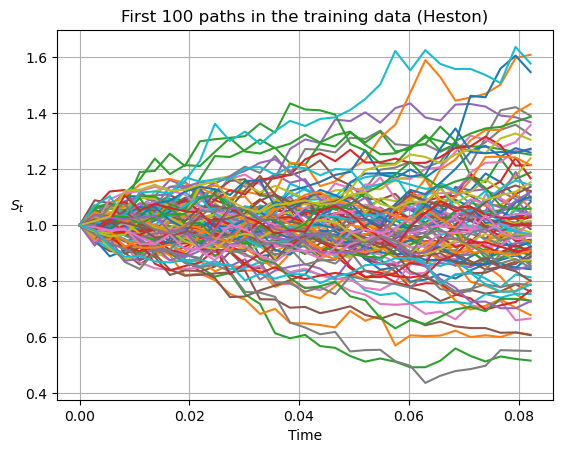

In [ ]:
#Write function to sample V
np.random.seed(0)
from scipy.stats import ncx2

sigma = 1
alpha = 4
b = 0.5
rho = -0.3
s0 = 1
v0 = 0.5
N = 30
T = N/365

def simulate_paths_V(m, N):
    V = np.zeros((m, N + 1))
    V[:, 0] = v0
    c = (sigma**2 * (1 - np.exp(-alpha * T/N))) / (4*alpha)

    df = 4*b*alpha/(sigma**2)
    nc = np.exp(-alpha*(T/N))

    for j in range(N):
        V[:, j+1] = c*ncx2.rvs(df = df, nc = nc*V[:, j]/c)
    
    return V


def simulate_paths_heston_broadie_kaya(m, N, V):
    S = np.zeros((m, N + 1))
    S[:, 0] = s0
    dt = T / N  # here T = 30/365, so dt = 1/365

    for j in range(N):
        Z = norm.rvs(size=m)

        S[:, j+1] = S[:, j] * np.exp(
            (rho / sigma) * ((V[:, j+1] - V[:, j]) - alpha * b * dt)
            + (alpha * rho / sigma - 0.5) * V[:, j] * dt
            + np.sqrt((1 - rho**2) * V[:, j] * dt) * Z
        )

    return S



V_train_heston = simulate_paths_V(m = int(1e5), N = N)
V_test_heston = simulate_paths_V(m = int(1e4), N = N)

S_train_heston = simulate_paths_heston_broadie_kaya(m=int(1e5), N = N, V = V_train_heston)
S_test_heston = simulate_paths_heston_broadie_kaya(m=int(1e4), N = N, V = V_test_heston)

S_T_train_heston = S_train_heston[:,-1]
S_T_test_heston = S_test_heston[:,-1]

payoff_train_heston = np.maximum(S_T_train_heston - K, 0)
payoff_test_heston = np.maximum(S_T_test_heston - K, 0)


for j in range(100):
    plt.plot(np.linspace(0, 30/365, 31), S_train_heston[j])
plt.title("First 100 paths in the training data (Heston)")
plt.xlabel('Time')
plt.ylabel(r'$S_t$  ', rotation = 360)
plt.grid(True)
plt.show()

### Question 2.b - Model implementation

In [ ]:
class shallow_model_heston(nn.Module):
    def __init__(self, hidden_dim, activation):
        super().__init__()
        self.shallow_model_heston = nn.Sequential(
            nn.Linear(2, hidden_dim, bias=True),
            activation,
            nn.Linear(hidden_dim, 1, bias=True)
        )

    def forward(self, S_t, V_t):
        # S_t, V_t: (batch,) or (batch,1)
        if S_t.dim() == 1:
            S_t = S_t.unsqueeze(1)
        if V_t.dim() == 1:
            V_t = V_t.unsqueeze(1)

        x = torch.cat([S_t, V_t], dim=1)   # (batch, 2)
        H_t = self.shallow_model_heston(x) # (batch, 1)
        return H_t.squeeze(-1)             # (batch,)


class deep_model_heston(nn.Module):
    def __init__(self, hidden_dim, activation):
        super().__init__()
        self.deep_model_heston = nn.Sequential(
            nn.Linear(2, hidden_dim, bias=True),
            activation,
            nn.Linear(hidden_dim, hidden_dim, bias=True),
            activation,
            nn.Linear(hidden_dim, 1, bias=True)
        )

    def forward(self, S_t, V_t):
        if S_t.dim() == 1:
            S_t = S_t.unsqueeze(1)
        if V_t.dim() == 1:
            V_t = V_t.unsqueeze(1)

        x = torch.cat([S_t, V_t], dim=1)   # (batch, 2)
        H_t = self.deep_model_heston(x)    # (batch, 1)
        return H_t.squeeze(-1)             # (batch,)

    
# CVar loss function
def cvar_loss(model, S_b, V_b, payoff_b, alpha):

    hedge_pnl = model(S_b, V_b)   # (batch,)
    X = payoff_b - hedge_pnl      # hedging loss = g(ST) - sum H dS

    w = model.w                   # scalar parameter

    excess = torch.clamp(X - w, min=0.0)
    loss = torch.mean(w + excess / (1 - alpha))
    return loss


# Class for the entire model 

class DeepHedgerHeston(nn.Module):
    def __init__(self, N, type_submodel, hidden_dim = 16, activation = nn.ReLU()):
        super().__init__()
        self.N = N
        if type_submodel == 'Shallow':
            self.submodels = nn.ModuleList([shallow_model_heston(hidden_dim = hidden_dim, activation = activation) for _ in range(N)])

        if type_submodel == 'Deep':
            self.submodels = nn.ModuleList([deep_model_heston(hidden_dim = hidden_dim, activation = activation) for _ in range(N)])
        
        elif (type_submodel != 'Deep' and type_submodel != 'Shallow'):
            print("Wrong specified model, please change type of submodel for H")
        
        self.w = nn.Parameter(torch.tensor(0.0))
    
    def forward(self, S_paths, V_paths):
        dS = S_paths[:, 1:] - S_paths[:, :-1]
        H_list = []

        for j in range(self.N):
            S_t_j = S_paths[:, j:j+1]
            V_t_j = V_paths[:, j:j+1]
            H_t_j = self.submodels[j](S_t_j, V_t_j)
            H_list.append(H_t_j)

        H = torch.stack(H_list, dim = 1)
        hedge_pnl = torch.sum(H * dS, dim = 1)
        return hedge_pnl



# Trainer for the Heston Model

def train_deep_hedger_Heston(model, 
                             S_train, V_train, payoff_train,
                             S_test,  V_test,  payoff_test,
                             alpha,
                             num_epochs=10, batch_size=1024, lr=1e-3,
                             device="cpu", plot_loss=True, print_statements=True):


    model.to(device)

    # Convert data to tensors
    S_train_t = torch.from_numpy(S_train).float().to(device)
    V_train_t = torch.from_numpy(V_train).float().to(device)
    payoff_train_t = torch.from_numpy(payoff_train).float().to(device)

    S_test_t = torch.from_numpy(S_test).float().to(device)
    V_test_t = torch.from_numpy(V_test).float().to(device)
    payoff_test_t = torch.from_numpy(payoff_test).float().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    m = S_train_t.size(0)
    train_losses = []
    test_losses  = []

    for epoch in range(num_epochs):
        perm = torch.randperm(m, device=device)

        for start in range(0, m, batch_size):
            idx = perm[start:start + batch_size]

            S_batch = S_train_t[idx]
            V_batch = V_train_t[idx]
            payoff_batch = payoff_train_t[idx]

            loss = cvar_loss(model, S_batch, V_batch, payoff_batch, alpha)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # record train loss (last mini-batch)
        train_losses.append(loss.item())

        # compute test loss
        with torch.no_grad():
            loss_test = cvar_loss(model, S_test_t, V_test_t, payoff_test_t, alpha)
        test_losses.append(loss_test.item())

        if print_statements:
            print(f"Epoch {epoch+1}/{num_epochs}, "
                  f"train loss = {loss.item():.6f}, "
                  f"test loss = {loss_test.item():.6f}")

    if plot_loss:
        epochs = range(1, num_epochs + 1)
        plt.plot(epochs, train_losses, label="Train loss")
        plt.plot(epochs, test_losses,  label="Test loss")
        plt.xlabel("Epoch")
        plt.ylabel("CVaR loss")
        plt.title("Train vs Test CVaR loss (Heston)")
        plt.legend()
        plt.show()

    return model, train_losses, test_losses


### Question 2.c - Model training

Training for alpha = 0.5
Epoch 1/100, train loss = 0.143606, test loss = 0.137686
Epoch 2/100, train loss = 0.121155, test loss = 0.121361
Epoch 3/100, train loss = 0.108014, test loss = 0.108470
Epoch 4/100, train loss = 0.103297, test loss = 0.102759
Epoch 5/100, train loss = 0.101631, test loss = 0.100895
Epoch 6/100, train loss = 0.099795, test loss = 0.100368
Epoch 7/100, train loss = 0.099470, test loss = 0.100492
Epoch 8/100, train loss = 0.100596, test loss = 0.100155
Epoch 9/100, train loss = 0.099662, test loss = 0.100014
Epoch 10/100, train loss = 0.099978, test loss = 0.100242
Epoch 11/100, train loss = 0.098614, test loss = 0.099943
Epoch 12/100, train loss = 0.099835, test loss = 0.099832
Epoch 13/100, train loss = 0.099264, test loss = 0.099737
Epoch 14/100, train loss = 0.100909, test loss = 0.100026
Epoch 15/100, train loss = 0.100566, test loss = 0.099827
Epoch 16/100, train loss = 0.099485, test loss = 0.099816
Epoch 17/100, train loss = 0.098679, test loss = 0.10001

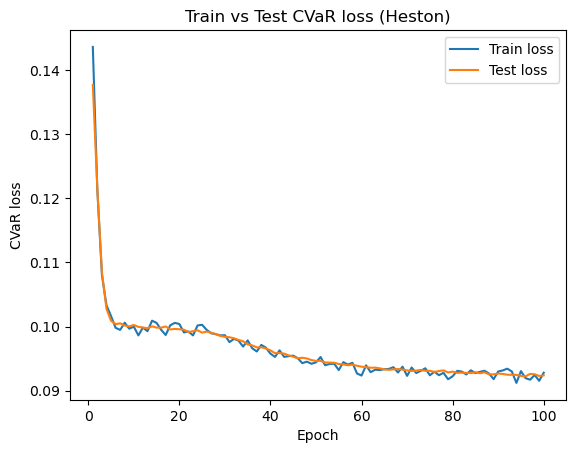

Training for alpha = 0.99
Epoch 1/30, train loss = 5.812567, test loss = 5.663325
Epoch 2/30, train loss = 3.544967, test loss = 3.673408
Epoch 3/30, train loss = 2.058020, test loss = 1.943895
Epoch 4/30, train loss = 0.862038, test loss = 0.806703
Epoch 5/30, train loss = 0.368932, test loss = 0.354010
Epoch 6/30, train loss = 0.216284, test loss = 0.227084
Epoch 7/30, train loss = 0.175240, test loss = 0.191973
Epoch 8/30, train loss = 0.172752, test loss = 0.174161
Epoch 9/30, train loss = 0.153467, test loss = 0.161014
Epoch 10/30, train loss = 0.152272, test loss = 0.156142
Epoch 11/30, train loss = 0.157826, test loss = 0.151525
Epoch 12/30, train loss = 0.148241, test loss = 0.146444
Epoch 13/30, train loss = 0.139249, test loss = 0.147001
Epoch 14/30, train loss = 0.140740, test loss = 0.143107
Epoch 15/30, train loss = 0.144282, test loss = 0.143417
Epoch 16/30, train loss = 0.138115, test loss = 0.143599
Epoch 17/30, train loss = 0.148684, test loss = 0.141048
Epoch 18/30, t

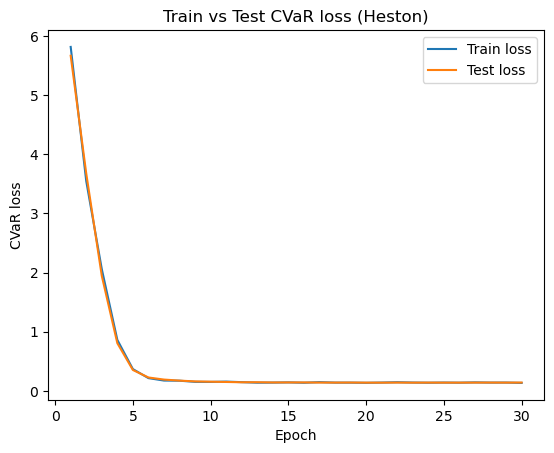

In [40]:
alpha1 = 0.5
model_1 = DeepHedgerHeston(N=N, type_submodel='Deep', hidden_dim = 64, activation = nn.Tanh())

print(f"Training for alpha = {alpha1}")
model_1, train_loss_1, test_loss_1 = train_deep_hedger_Heston(
    model_1,
    S_train_heston, V_train_heston, payoff_train_heston,
    S_test_heston,  V_test_heston,  payoff_test_heston,
    alpha=alpha1,
    num_epochs=100,
    batch_size=4096,
    lr=1e-3,
    device='cpu',
    plot_loss=True,
    print_statements=True
)

alpha2 = 0.99
model_2 = DeepHedgerHeston(N = N, type_submodel='Deep', hidden_dim = 64, activation=nn.Tanh())
print(f"Training for alpha = {alpha2}")
model_2, train_loss_2, test_loss_2 = train_deep_hedger_Heston(
    model_2,
    S_train_heston, V_train_heston, payoff_train_heston,
    S_test_heston,  V_test_heston,  payoff_test_heston,
    alpha=alpha2,
    num_epochs = 30,
    batch_size=4096,
    lr=1e-3,
    device='cpu',
    plot_loss=True,
    print_statements=True
)

Note that we have manually selected the 2 following configurations for the models above after playing with different hyperparameters, including the activation function, hidden dimensions, and number of epochs. Specifically, the model with $\alpha=0.99$ converges much faster than the model with $\alpha=0.5$ (100 epochs vs. 30 epochs).

### Question 2.d - Price comparison

In [41]:
# Print the prices p for alpha=0.5 

with torch.no_grad():
    S_test_t = torch.from_numpy(S_test_heston).float()
    V_test_t = torch.from_numpy(V_test_heston).float()
    payoff_test_t = torch.from_numpy(payoff_test_heston).float()

    p_hat_05 = cvar_loss(model_1, S_test_t, V_test_t, payoff_test_t, alpha=0.5).item()

print(f"Estimated price p (alpha = 0.5) from full test set: {p_hat_05:.6f}")

# Print the prices p for alpha=0.99
with torch.no_grad():
    S_test_t = torch.from_numpy(S_test_heston).float()
    V_test_t = torch.from_numpy(V_test_heston).float()
    payoff_test_t = torch.from_numpy(payoff_test_heston).float()

    p_hat_099 = cvar_loss(model_2, S_test_t, V_test_t, payoff_test_t, alpha=0.99).item()

print(f"Estimated price p (alpha = 0.99) from full test set: {p_hat_099:.6f}")
 

Estimated price p (alpha = 0.5) from full test set: 0.092386
Estimated price p (alpha = 0.99) from full test set: 0.141765


$p_{0.99} > p_{0.5}$ because CVaR $_{0.99}$ penalizes extreme tail losses more strongly, the optimal hedging requires more initial capital, so the price is higher.



### Question 2.e - Price comparison

=== Empirical statistics on hedging losses ===
alpha = 0.5  -> mean = 0.000797, std = 0.016251
alpha = 0.99 -> mean = -0.051647, std = 0.027561


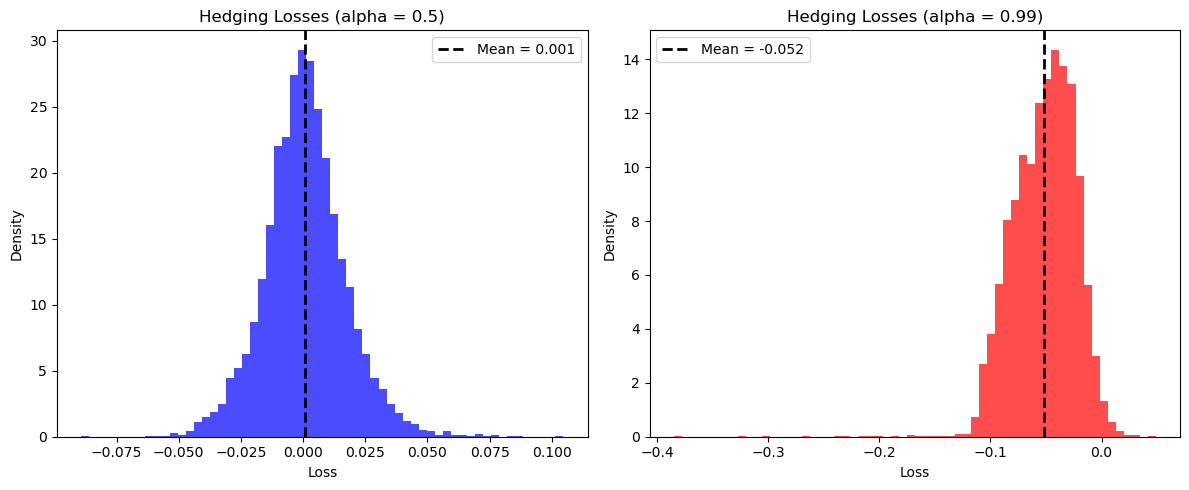

In [42]:
def compute_hedging_losses(model, S_test, V_test, payoff_test):
    model.eval()
    device = next(model.parameters()).device

    S_t = torch.from_numpy(S_test).float().to(device)
    V_t = torch.from_numpy(V_test).float().to(device)
    payoff_t = torch.from_numpy(payoff_test).float().to(device)

    with torch.no_grad():
        hedge_pnl = model(S_t, V_t)
        p = model.w.item()
        losses = payoff_t - p - hedge_pnl

    return losses.cpu().numpy(), p



losses_05, p05 = compute_hedging_losses(model_1, S_test_heston, V_test_heston, payoff_test_heston)
losses_99, p99 = compute_hedging_losses(model_2, S_test_heston, V_test_heston, payoff_test_heston)

mean_05 = losses_05.mean()
mean_99 = losses_99.mean()

print("=== Empirical statistics on hedging losses ===")
print(f"alpha = 0.5  -> mean = {mean_05:.6f}, std = {losses_05.std():.6f}")
print(f"alpha = 0.99 -> mean = {mean_99:.6f}, std = {losses_99.std():.6f}")


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.hist(losses_05, bins=60, density=True, alpha=0.7, color='blue')
plt.axvline(mean_05, linestyle='--', color='black', linewidth=2, label=f"Mean = {mean_05:.3f}")
plt.title("Hedging Losses (alpha = 0.5)")
plt.xlabel("Loss")
plt.ylabel("Density")
plt.legend()


plt.subplot(1,2,2)
plt.hist(losses_99, bins=60, density=True, alpha=0.7, color='red')
plt.axvline(mean_99, linestyle='--', color='black', linewidth=2, label=f"Mean = {mean_99:.3f}")
plt.title("Hedging Losses (alpha = 0.99)")
plt.xlabel("Loss")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()


The α = 0.5 model produces losses centered near zero, reflecting a strategy focused on average performance with moderate risk aversion. The α = 0.99 model shows a left-shifted distribution with a more negative mean, because the higher CVaR level forces the hedger to charge a larger price and prioritize protection against extreme tail losses.